# 🎓 Online Learning Student Dropout Analysis
## Can we predict who will drop out before it's too late?

Online education has exploded globally — but dropout rates remain alarmingly high. 
This notebook explores **what separates students who complete courses from those who abandon them.**

### Dataset Overview
- 5,000 student records
- 15 features covering behavior, engagement, and academic performance
- Goal: Understand dropout patterns through deep EDA

### What We'll Explore
- 📊 Who is dropping out? (age, region, demographics)
- 📈 How does engagement affect dropout?
- 🎯 Which factors matter most?
- 💡 Key insights for online education platforms


In [28]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Loading the Dataset
Let's load the data and take our first look at its structure.


In [29]:
df = pd.read_csv("student_dropout_dataset.csv")

# Basic Overview
print(f'Dataset Shape:{df.shape}')
print(f'Total Students:{df.shape[0]}')
print(f'Total Features:{df.shape[1]}')
print('\n--- First 5 rows ---')
df.head()

Dataset Shape:(5000, 15)
Total Students:5000
Total Features:15

--- First 5 rows ---


,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


## 🔍 Data Types & Missing Values
Understanding what kind of data we have and checking for any missing values.

In [30]:
# Check data types and null values
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n✅ Total missing values: {df.isnull().sum().sum()}")

--- Data Types ---
student_id                 object
age                         int64
region                     object
enroll_date                object
exam_season                 int64
courses_enrolled            int64
completed_assignments       int64
completion_rate           float64
login_frequency           float64
last_activity_days_ago      int64
forum_posts_count           int64
dropout_score             float64
label                       int64
label_multiclass            int64
label_name                 object
dtype: object

--- Missing Values ---
student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64


## 🎯 Target Variable Analysis
Who is dropping out? Let's see the distribution of our target variable.

In [31]:
# Checking dropout distribution
print('--- Dropout Distribution ---')
print(df['label_name'].value_counts())
print(f'\nDropout Rate: {df['label'].mean() * 100:.2f}%')

--- Dropout Distribution ---
label_name
active     1704
at-risk    1663
dropped    1633
Name: count, dtype: int64

Dropout Rate: 65.92%


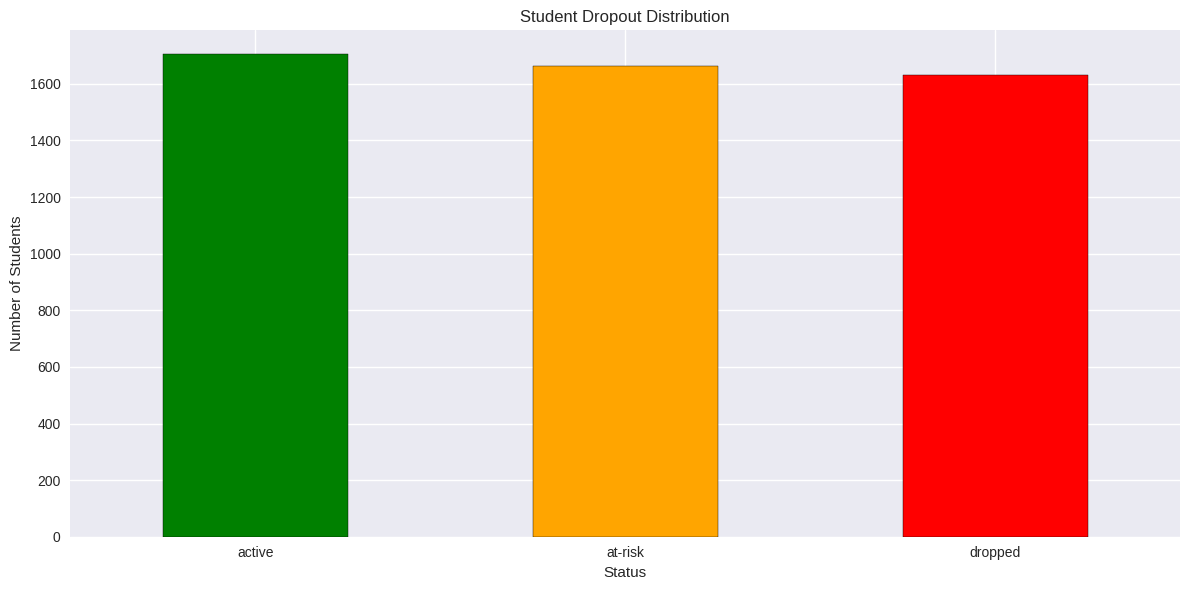

In [32]:
# Visualize
plt.figure(figsize=(12,6))
df['label_name'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'], edgecolor='black')
plt.title('Student Dropout Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 💡 Insight
**65.92% of students are either at-risk or have already dropped out!**

This is alarmingly high. Only 1 in 3 students successfully completes their course.
This suggests a serious engagement problem in online learning platforms — 
students enroll with motivation but struggle to stay committed.

## 👥 Age Distribution
Does age affect dropout rates? Let's find out.


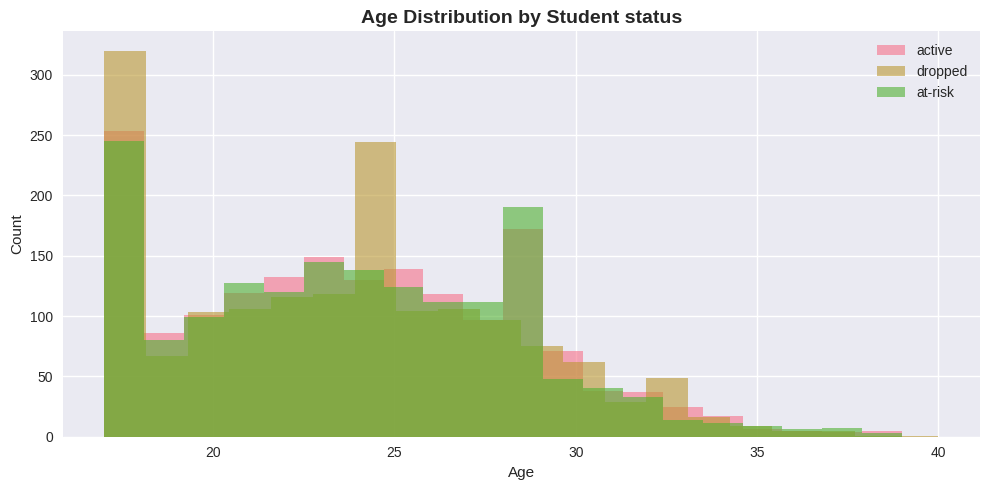

label_name
active     23.856808
at-risk    23.816597
dropped    23.529700
Name: age, dtype: float64


In [33]:
# Age Distribution by dropout status
plt.figure(figsize=(10,5))
for label in df['label_name'].unique():
    subset = df[df['label_name'] == label]['age']
    subset.hist(alpha=0.6, label=label, bins=20)

plt.title('Age Distribution by Student status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label_name')['age'].mean())

### 💡 Insight
**Age has almost NO impact on dropout!**
- Active avg age: 23.85
- At-risk avg age: 23.81  
- Dropped avg age: 23.53

All three groups have nearly identical average ages (~23-24 years).
This tells us: **dropout is NOT an age problem — it's an engagement problem.**
We need to look at behavior features like login frequency and completion rate.

## 📈 Completion Rate vs Dropout
Does how much a student completes predict if they'll drop out?

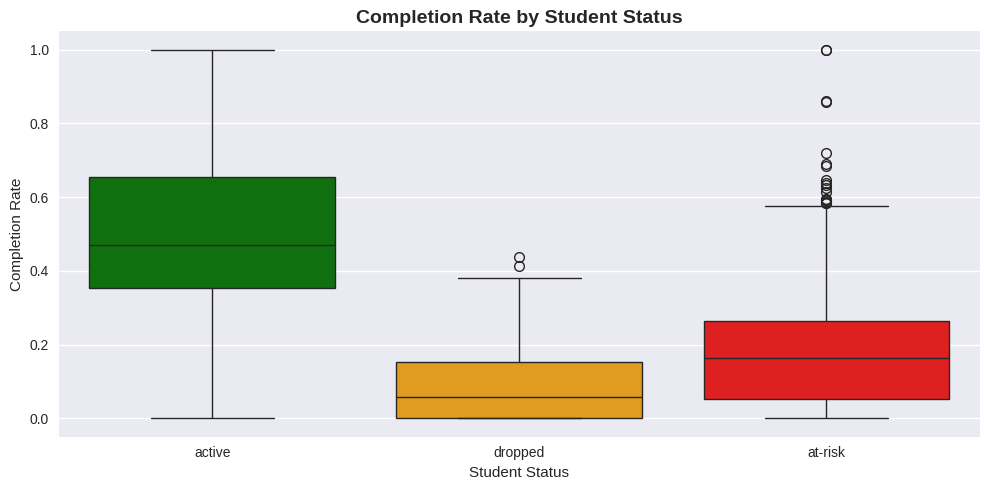

label_name
active     0.512990
at-risk    0.175312
dropped    0.085271
Name: completion_rate, dtype: float64


In [34]:
# Completion rate by Student Status
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='label_name', y='completion_rate', hue='label_name', palette=['green', 'orange', 'red'])
plt.title('Completion Rate by Student Status', fontsize=14, fontweight='bold')
plt.xlabel('Student Status')
plt.ylabel('Completion Rate')
plt.tight_layout()
plt.show()

print(df.groupby('label_name')['completion_rate'].mean())

### 💡 Insight
**Completion rate is the strongest predictor of dropout!**
- Active students complete **51%** of their coursework
- At-risk students complete only **17%**
- Dropped students complete just **8%**

A student completing less than 20% of their coursework 
is a strong early warning signal of dropout.
Online platforms should trigger intervention alerts 
when completion rate drops below 20%.


## 🔐 Login Frequency vs Dropout
Do students who login more stay enrolled?

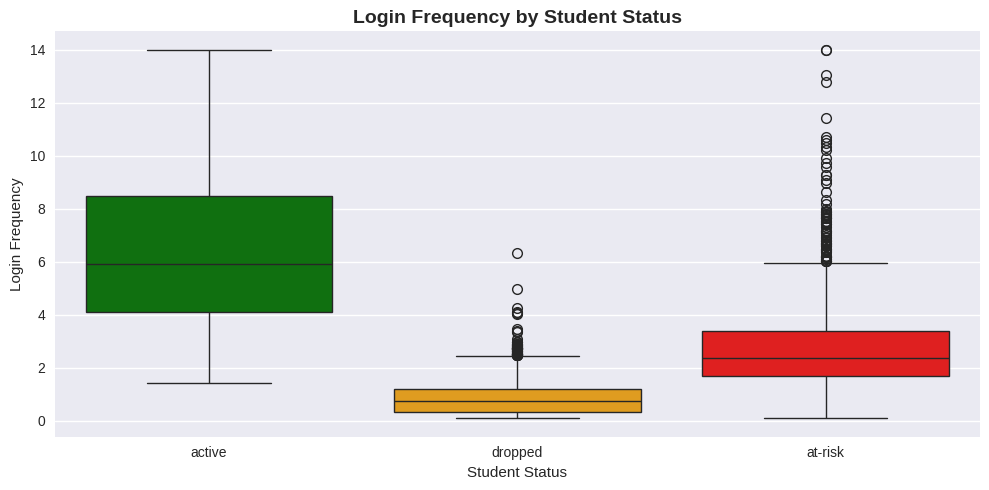

label_name
active     6.668122
at-risk    2.706254
dropped    0.861066
Name: login_frequency, dtype: float64


In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='label_name', y='login_frequency', hue='label_name', palette=['green', 'orange', 'red'])
plt.title('Login Frequency by Student Status', fontsize=14, fontweight='bold')
plt.xlabel('Student Status')
plt.ylabel('Login Frequency')
plt.tight_layout()
plt.show()

print(df.groupby('label_name')['login_frequency'].mean())

### 💡 Insight
**Login frequency drops dramatically before dropout!**
- Active students login **6.7x per period** on average
- At-risk students login only **2.7x** — 60% less than active
- Dropped students logged in less than **once (0.86)**

This is a powerful early warning signal:
> If a student's login frequency drops below 2, 
> immediate intervention is needed.

Online platforms can use login frequency as a 
**real-time dropout alert system.**

## 🔥 Correlation Heatmap
Which features are most related to dropout score?

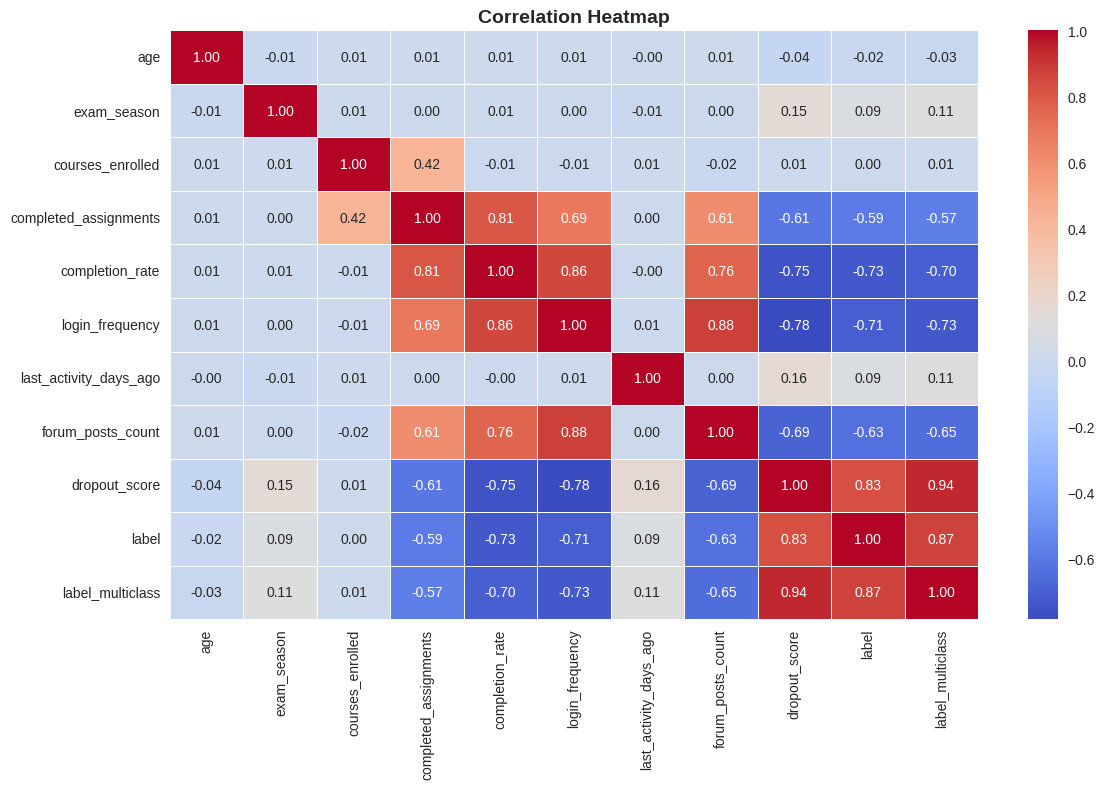

In [36]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number').drop('student_id' if 'student_id' in df.columns else [], axis=1, errors='ignore')
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 💡 Insight
**Top predictors of dropout (from correlation):**
1. 🥇 Completion rate (-0.73) — strongest signal
2. 🥈 Login frequency (-0.71) — second strongest  
3. 🥉 Forum posts (-0.63) — engagement matters
4. Completed assignments (-0.59) — effort matters
5. Age (-0.02) — completely irrelevant!

**Key takeaway:** Dropout is purely a **behavioral and engagement problem** — not demographic.
Negative means higher value  = less likely to drop out

## 🏁 Key Insights & Conclusion

### 📊 What We Discovered
1. **65.92% dropout rate** — massive problem in online education
2. **Completion rate is king** — active students complete 51% vs dropped 8%
3. **Login frequency tells the story** — dropped students logged in less than once
4. **Age doesn't matter** — all groups average ~23 years
5. **Forum engagement predicts success** — active students post more

### 💡 Recommendations for Online Platforms
- 🚨 Alert students when completion rate drops below 20%
- 📧 Send re-engagement emails when login frequency drops below 2
- 🎯 Gamify forum participation to boost engagement
- 📱 Push notifications for inactive students after 7 days

### 🎯 Next Steps
- Build a dropout prediction model using these features
- XGBoost or Random Forest would work well here